# Part 2 — Latent geometry: contractive metric × weight sweep

Same `contractive-20260905-01` campaign as `part_1` (12 `(penalty_metric, weight)` cells ×
5 repetitions). Extends `23_08_26_architecture_predictive/part_7_latent_bce_vs_all.ipynb`'s
canonicalized-latent geometry toolkit (`analysis.autoencoder.latent.sphere_geometry`) from a
fixed 6-objective comparison to the two-dimensional sweep, to check directly whether the
`methodology.md` diagnosis — `+contractive` collapses the code cloud toward one point
(`cloud_asymmetry` up, `effective_rank`/`trace(Cov(u))` down, `part_4`/`part_7`) — is worse,
the same, or better for `spectral`/`hinged` than for the already-characterized `frobenius`
metric, and how it moves with $\lambda_{CAE}$.

**Baseline**: `bce-baseline-20260905-01` (5 repetitions, plain `balanced_bce`, no
`ContractiveLoss`), same-split as the sweep — see `part_1`'s introduction for the
byte-identical split verification. Loaded into the same `wrapper`/`shared_partitions` as
every sweep model, not a second context.

**Cost scope**: `cloud_asymmetry`/`dimension_usage` are computed for all 60 sweep models +
5 baseline models (cheap — one encoder forward pass each). `angular_sensitivity_curve` and
`rsa_spearman` are computed for repetition 0 only per `(metric, weight)` cell (12 models) +
the baseline's own repetition 0, matching `part_7`'s own "`rep_00` only" precedent for these
two — the perturbation sweep requires `len(EPSILONS)` extra forward passes per model and RSA
requires per-pair label lookups, so this is a real cost cut, not an incidental omission.
**Both `train` and `test` are a deterministic 15% pixel subsample** (`PIXEL_FRACTION`,
seeded) rather than `part_7`'s full `test` split — the per-model decode cost (`dataset[index]`,
~30 spectra/s, paid once per split via materialization, not per model) makes the full split
too slow across 65 models.

In [1]:
import itertools
import os
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt

current_path = Path.cwd().resolve()
repository_root = next(path for path in (current_path, *current_path.parents) if (path / "pyproject.toml").is_file())
os.chdir(repository_root)

from msi_autoencoder_wrapper import MSIAutoEncoderWrapper
from msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader import read_entropy_campaign
from msi_autoencoder_wrapper.analysis.autoencoder.latent import sphere_geometry as geometry
from msi_autoencoder_wrapper.visualization import resolve_theme
from msi_autoencoder_wrapper.visualization.metrics import plot_violin_with_points

2026-09-05 17:25:10,897 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 17:25:10,904 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


2026-09-05 17:25:11,877 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 3 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders.presets'.


2026-09-05 17:25:11,879 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 22 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.autoencoders'.


2026-09-05 17:25:11,882 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 0 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures.types.schema'.


2026-09-05 17:25:11,883 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:25:11,902 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.models.datasets.strategies'.


2026-09-05 17:25:12,058 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 16 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions.autoencoder'.


2026-09-05 17:25:12,059 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 20 implementation module(s) in package 'msi_autoencoder_wrapper.training.criterions'.


## Config

Task-to-hyperparameter resolution uses `read_entropy_campaign` against each campaign's
`configs/entropy-runs/<id>/plan/status/` manifests — the authoritative record of what
`(penalty_metric, weight, repetition)` each `task_id` ran, same as `part_1`.

In [2]:
WORKSPACE = Path("data/kidney_workspace")
MODEL_CONTEXT = "kidney"
CAMPAIGN_ID = "contractive-20260905-01"
MODEL_STORE_DIRECTORY = WORKSPACE / "models" / MODEL_CONTEXT

PENALTY_METRICS = ["frobenius", "spectral", "hinged"]
WEIGHTS = [1e-5, 1e-4, 1e-3, 1e-2]
REPETITIONS = list(range(5))
BATCH_SIZE = 256
RANDOM_SEED = 42
PAIR_COUNT = 20000
EPSILONS = [0.0, 0.01, 0.03, 0.1, 0.3, 1.0]
TARGET_FIELD = "molecule"

# Fraction of each split's pixels actually encoded. The dataset decodes a spectrum from
# the raw reader on every `__getitem__` (~30 spectra/s measured), so decoding both splits
# once per model, across 65 models, would take hours; a deterministic subsample plus
# materializing each split ONCE (below), shared across every model, brings this to minutes.
PIXEL_FRACTION = 0.15


def read_status(campaign_id: str, *run_subdirectories: str):
    status_directory = WORKSPACE / "configs" / "entropy-runs" / campaign_id
    for subdirectory in run_subdirectories:
        status_directory = status_directory / subdirectory
    return read_entropy_campaign(
        status_directory / "plan" / "status", MODEL_STORE_DIRECTORY, load_artifacts=False
    )


def contractive_params(task) -> dict:
    return task.grid_parameters["objectives"]["regularization"]["contractive"]


sweep_tasks = [task for task in read_status(CAMPAIGN_ID) if task.status == "completed"]
model_name_by_cell: dict[tuple[str, float], dict[int, str]] = {}
for task in sweep_tasks:
    params = contractive_params(task)
    cell = (params["params"]["penalty_metric"], float(params["weight"]))
    model_name_by_cell.setdefault(cell, {})[task.repetition] = f"{CAMPAIGN_ID}__{task.task_id}"

assert {cell: sorted(reps) for cell, reps in model_name_by_cell.items()} == {
    (metric, weight): REPETITIONS for metric in PENALTY_METRICS for weight in WEIGHTS
}, "campaign status manifests do not cover the expected 12-cell x 5-repetition grid"


def model_name_for(metric: str, weight: float, repetition: int) -> str:
    return model_name_by_cell[(metric, weight)][repetition]


# --- Baseline -- same split as the sweep (verified in part_1's introduction).
BASELINE_CAMPAIGN_ID = "bce-baseline-20260905-01"
BASELINE_LABEL = "bce baseline (same split, 5 repetitions)"

baseline_model_name_by_rep = {
    task.repetition: f"{BASELINE_CAMPAIGN_ID}__{task.task_id}"
    for task in read_status(BASELINE_CAMPAIGN_ID)
    if task.status == "completed"
}


def baseline_model_name(repetition: int) -> str:
    return baseline_model_name_by_rep[repetition]


theme = resolve_theme(None)
theme.apply()
METRIC_COLOR = {metric: theme.color_for_model(metric, index) for index, metric in enumerate(PENALTY_METRICS)}

# Shared x-axis ordering for every violin+points panel below: all 12 sweep cells, grouped
# by metric then weight, plus baseline as the trailing position.
cell_order = [(metric, weight) for metric in PENALTY_METRICS for weight in WEIGHTS]
cell_labels = [f"{metric}\n{weight:g}" for metric, weight in cell_order] + ["baseline"]
cell_color = [METRIC_COLOR[metric] for metric, _ in cell_order] + [theme.baseline_color]

2026-09-05 17:25:12,243 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 60 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status'.


2026-09-05 17:25:12,958 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/contractive-20260905-01/plan/status': 60 task(s) read.


2026-09-05 17:25:12,959 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:71 | Reading 5 entropy task manifest(s) from 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status'.


2026-09-05 17:25:13,011 | INFO     | msi_autoencoder_wrapper.analysis.autoencoder.experiments.entropy_status_reader:88 | Entropy campaign at 'data/kidney_workspace/configs/entropy-runs/bce-baseline-20260905-01/plan/status': 5 task(s) read.


## Environment workaround (same pattern as `part_1`)

In [3]:
# Only the sweep needs this: `load_configuration` re-resolves the raw reader/annotation
# paths baked into that model's own saved config. The baseline is attached via
# `models_manager.load_model` under this same context (architecture/weights only, no
# re-resolution of its own saved paths), so it needs no symlink of its own.
SCRATCH_WORKSPACE_ROOT = Path("/tmp/ms488923/msi-wrapper/contractive-20260905-01/workspace")
SCRATCH_WORKSPACE_ROOT.parent.mkdir(parents=True, exist_ok=True)
if not SCRATCH_WORKSPACE_ROOT.is_symlink():
    SCRATCH_WORKSPACE_ROOT.symlink_to(WORKSPACE.resolve())

## Load every (metric, weight, repetition), encode, canonicalize

### Methodology
#### Theoretical
- Before any geometry comparison, canonicalization must be verified for every model
  (`geometria_latentu.md`'s Część V checklist, `part_7`'s precedent), then `cloud_asymmetry`
  and `dimension_usage` computed per `(metric, weight, repetition, split)`.

#### Implementation
- `materialize_split` decodes each split's `PIXEL_FRACTION` pixel subsample from the raw
  reader exactly ONCE (`dataset[index]`, measured ~30 spectra/s) into a resident tensor,
  shared by every one of the 65 models. `encode_latent` then runs a pure batched GPU
  forward pass per model on that tensor — canonicalized via `geometry.canonicalize(z,
  gamma, beta)` using each model's own bottleneck `LayerNorm`
  (`geometry.encoder_layer_norm_parameters`). REMARK: an earlier version called a fresh
  `encode_ids` (re-decoding from `dataset[index]`) once per model per split — at 65 models
  x 2 splits that re-pays the ~30 spectra/s decode cost 130 times over; materializing once
  turns that into a single one-time pass.

### Notes

In [4]:
wrapper = MSIAutoEncoderWrapper(project_path=str(WORKSPACE))
wrapper.workspace.set_default_image_path(MODEL_CONTEXT)

first_metric, first_weight = PENALTY_METRICS[0], WEIGHTS[0]
wrapper.load_configuration(model_name=model_name_for(first_metric, first_weight, 0))
shared_partitions = wrapper.active_dataset.create_partitions()


def materialize_split(split_name: str, fraction: float = PIXEL_FRACTION, seed: int = RANDOM_SEED) -> dict:
    dataset = getattr(shared_partitions, split_name)
    total = len(dataset)
    sample_size = max(1, int(round(total * fraction)))
    indices = sorted(np.random.default_rng(seed).choice(total, size=sample_size, replace=False).tolist())
    spectra, targets = [], []
    for index in indices:
        _, spectrum, target, _mask = dataset[index]
        spectra.append(spectrum)
        targets.append(target[TARGET_FIELD])
    return {
        "spectra": torch.stack(spectra).float(),
        "targets": torch.stack(targets).numpy(),
        "sampled": sample_size,
        "total": total,
    }


materialized = {"train": materialize_split("train"), "test": materialize_split("test")}
for split_name, split_data in materialized.items():
    print(f"{split_name}: sampled {split_data['sampled']}/{split_data['total']} pixels ({PIXEL_FRACTION:.0%})")


def encode_latent(model, device, spectra: torch.Tensor) -> np.ndarray:
    latents = []
    with torch.no_grad():
        for start in range(0, len(spectra), BATCH_SIZE):
            batch = spectra[start : start + BATCH_SIZE].to(device)
            latents.append(model(batch)["latent_space"].cpu().numpy())
    return np.concatenate(latents, axis=0)


u_by_split_cell = {}
verification_rows = []
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        for repetition in REPETITIONS:
            model_name = model_name_for(metric, weight, repetition)
            if (metric, weight, repetition) == (first_metric, first_weight, 0):
                model = wrapper.active_model
            else:
                model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
            model.eval()
            device = next(model.parameters()).device
            gamma, beta = geometry.encoder_layer_norm_parameters(model)
            for split_name, split_data in materialized.items():
                z = encode_latent(model, device, split_data["spectra"])
                u = geometry.canonicalize(z, gamma, beta)
                u_by_split_cell[(metric, weight, repetition, split_name)] = u
                if repetition == 0:
                    verification_rows.append({
                        "penalty_metric": metric, "weight": weight, "split": split_name,
                        **geometry.verify_canonicalization(u),
                    })
    print(f"{metric}: all weights x repetitions encoded")

u_by_split_baseline_rep = {}
for repetition in REPETITIONS:
    model = wrapper.models_manager.load_model(
        img_name=MODEL_CONTEXT, model_name=baseline_model_name(repetition), strict=True
    )
    model.eval()
    device = next(model.parameters()).device
    gamma, beta = geometry.encoder_layer_norm_parameters(model)
    for split_name, split_data in materialized.items():
        z = encode_latent(model, device, split_data["spectra"])
        u = geometry.canonicalize(z, gamma, beta)
        u_by_split_baseline_rep[(repetition, split_name)] = u
        if repetition == 0:
            verification_rows.append({
                "penalty_metric": "baseline", "weight": float("nan"), "split": split_name,
                **geometry.verify_canonicalization(u),
            })
print("baseline: 5 repetitions encoded")

pd.DataFrame(verification_rows)

2026-09-05 17:25:13,084 | INFO     | msi_autoencoder_wrapper.core.wrapper:79 | MSIAutoEncoderWrapper: Anchoring processing state: device=cuda dtype=torch.float32


2026-09-05 17:25:13,086 | INFO     | msi_autoencoder_wrapper.core.mixins.context_manager.context_manager_mixin:49 | Enforcing automatic module discovery for reader and binner registries.


2026-09-05 17:25:13,087 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 2 implementation module(s) in package 'msi_autoencoder_wrapper.readers.strategies'.


2026-09-05 17:25:13,088 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 1 implementation module(s) in package 'msi_autoencoder_wrapper.binners.binners_strategies'.


2026-09-05 17:25:13,090 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 6 implementation module(s) in package 'msi_autoencoder_wrapper.binners.inverse_strategies'.


...

2026-09-05 17:26:32,719 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-05 17:26:32,723 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:26:32,729 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


baseline: 5 repetitions encoded


,penalty_metric,weight,split,max_abs_row_sum,expected_norm,mean_row_norm,max_abs_norm_deviation
0,frobenius,0.00001,train,8.447354e-07,3.162278,3.162276,5.325069e-06
1,frobenius,0.00001,test,7.178847e-07,3.162278,3.162276,4.950727e-06
2,frobenius,0.00010,train,8.291938e-07,3.162278,3.162277,1.941436e-06
3,frobenius,0.00010,test,7.301561e-07,3.162278,3.162277,1.845890e-06
4,frobenius,0.00100,train,7.741383e-07,3.162278,3.162277,1.538563e-06
5,frobenius,0.00100,test,6.019494e-07,3.162278,3.162277,1.064629e-06
6,frobenius,0.01000,train,7.484143e-07,3.162278,3.162277,1.043678e-06
7,frobenius,0.01000,test,6.129156e-07,3.162278,3.162277,9.766458e-07
8,spectral,0.00001,train,9.096007e-07,3.162278,3.162273,1.314875e-05
9,spectral,0.00001,test,6.386053e-07,3.162278,3.162273,1.199895e-05


## Is there any structure at all — random-pair cos θ distribution

### Methodology
#### Theoretical
- `part_7`'s first geometry check, ported here: compare the observed random-pair
  $\cos\theta$ distribution against the closed-form uniform-sphere null
  (`geometria_latentu.md` §3.1, $\operatorname{Var}[\cos\theta]=1/(D-1)$ for i.i.d. uniform
  points). A summary mean/sd cannot show whether the spread is unimodal, skewed, or
  bimodal — only the raw distribution can, which is exactly `part_6`'s reason for
  `plot_violin_with_points` over a bare mean+sd pair.

#### Implementation
- `geometry.structure_test(u, rng, pair_count, return_samples=True)` on repetition 0 of
  every `(penalty_metric, weight)` cell plus baseline (matching `part_7`'s per-objective,
  single-repetition scope for this check), then a violin+points panel per split.

### Notes

In [5]:
structure_rng = np.random.default_rng(RANDOM_SEED + 1)
cos_theta_samples_by_cell = {}
structure_rows = []
for split_name in materialized:
    for metric, weight in cell_order:
        u = u_by_split_cell[(metric, weight, 0, split_name)]
        pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
        result = geometry.structure_test(u, structure_rng, pair_count=pairs, return_samples=True)
        cos_theta_samples_by_cell[(split_name, metric, weight)] = result.pop("cos_theta_samples")
        structure_rows.append({"split": split_name, "penalty_metric": metric, "weight": weight, **result})
    u_baseline = u_by_split_baseline_rep[(0, split_name)]
    pairs = min(PAIR_COUNT, u_baseline.shape[0] * (u_baseline.shape[0] - 1))
    result = geometry.structure_test(u_baseline, structure_rng, pair_count=pairs, return_samples=True)
    cos_theta_samples_by_cell[(split_name, "baseline", None)] = result.pop("cos_theta_samples")
    structure_rows.append({"split": split_name, "penalty_metric": "baseline", "weight": float("nan"), **result})

pd.DataFrame(structure_rows)

,split,penalty_metric,weight,observed_mean_cos_theta,observed_sd_cos_theta,uniform_baseline_sd_cos_theta,effective_dimension
0,train,frobenius,0.00001,0.741431,0.192120,0.333333,8.0
1,train,frobenius,0.00010,0.914678,0.077472,0.333333,8.0
2,train,frobenius,0.00100,0.973537,0.024318,0.333333,8.0
3,train,frobenius,0.01000,0.991694,0.007177,0.333333,8.0
4,train,spectral,0.00001,0.549751,0.323355,0.333333,8.0
5,train,spectral,0.00010,0.617645,0.305984,0.333333,8.0
6,train,spectral,0.00100,0.659096,0.321272,0.333333,8.0
7,train,spectral,0.01000,0.793439,0.058304,0.333333,8.0
8,train,hinged,0.00001,0.547665,0.287665,0.333333,8.0
9,train,hinged,0.00010,0.582523,0.285257,0.333333,8.0


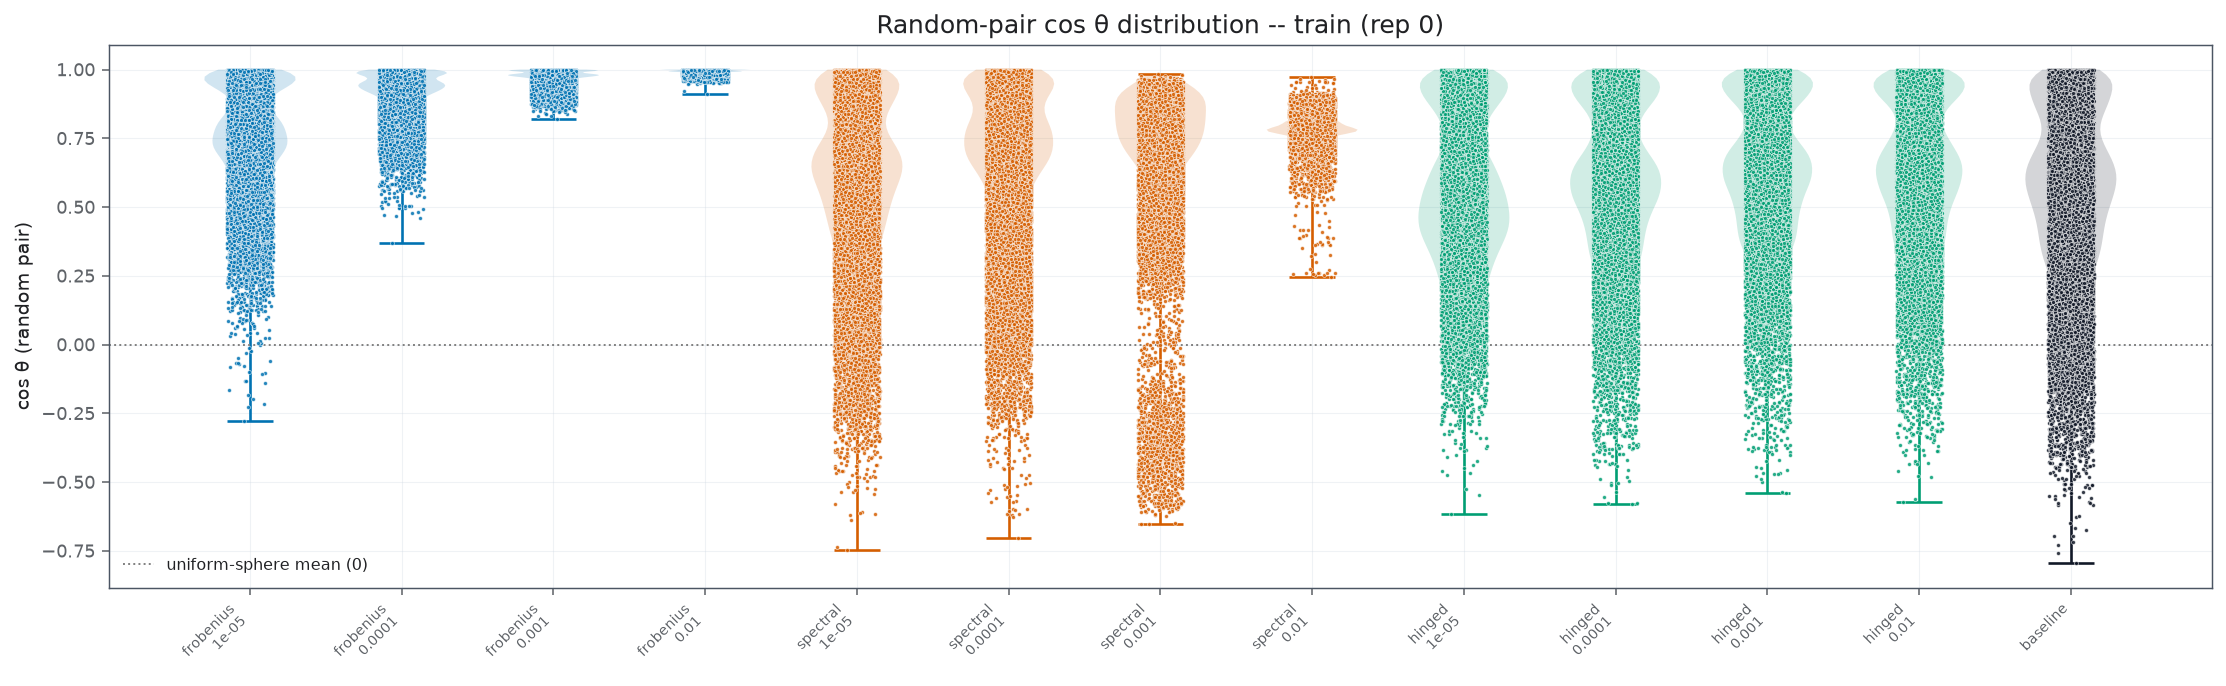

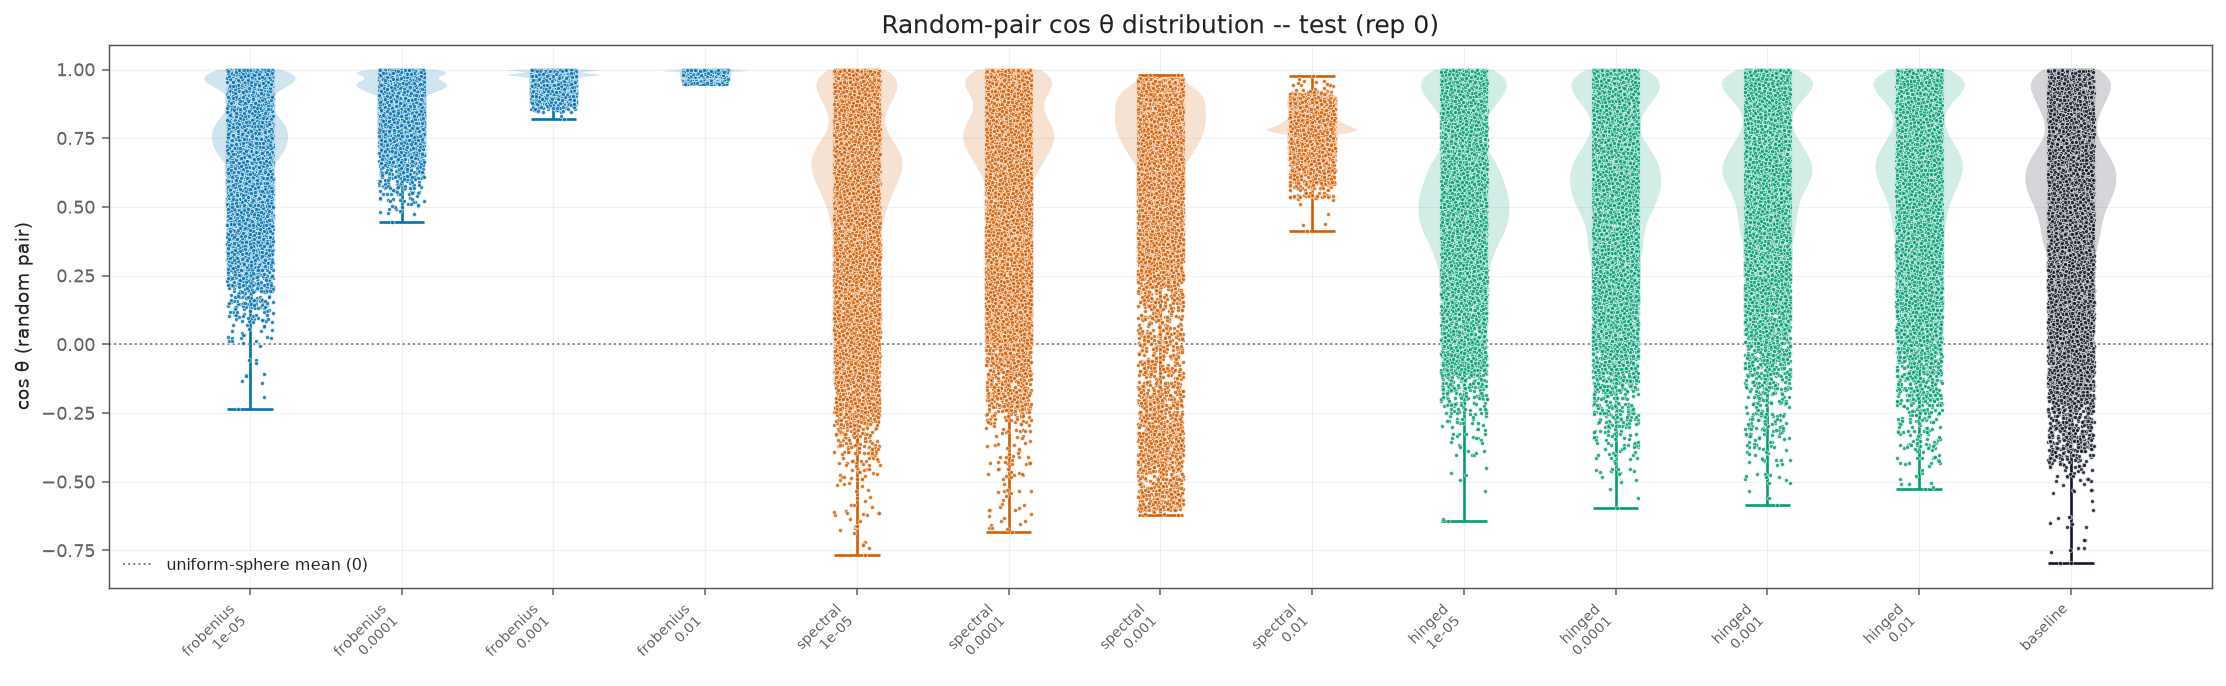

In [6]:
for split_name in materialized:
    figure, ax = plt.subplots(figsize=(16.0, 5.0), dpi=theme.figure_dpi)
    for position, (metric, weight) in enumerate(cell_order):
        plot_violin_with_points(
            cos_theta_samples_by_cell[(split_name, metric, weight)], position=position, ax=ax,
            width=0.6, color=cell_color[position], point_size=4.0, jitter=0.15,
        )
    plot_violin_with_points(
        cos_theta_samples_by_cell[(split_name, "baseline", None)], position=len(cell_order), ax=ax,
        width=0.6, color=cell_color[-1], point_size=4.0, jitter=0.15,
    )
    ax.axhline(0.0, color="grey", linestyle=":", linewidth=1, label="uniform-sphere mean (0)")
    ax.set_xticks(range(len(cell_labels)))
    ax.set_xticklabels(cell_labels, rotation=45, ha="right", fontsize=7)
    ax.set(ylabel="cos θ (random pair)", title=f"Random-pair cos θ distribution -- {split_name} (rep 0)")
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
    ax.legend(fontsize=8, frameon=theme.legend_frame)
    figure.tight_layout()

## `cloud_asymmetry` and `dimension_usage` sweep

### Methodology
#### Theoretical
- `cloud_asymmetry(u) = ||mean(u)||^2 / D` and `dimension_usage(u)` (`effective_rank`,
  `trace(Cov(u))`, `participation_ratio`) are the two static-geometry signatures `part_4`
  found separating collapsed from non-collapsed latents. Swept over `(metric, weight)`
  with the 5-repetition spread as the seed-noise band, against the baseline.

#### Implementation
- Computed per `(metric, weight, repetition, split)` from the `u` cached in the previous
  cell; no re-encoding here.

### Notes

In [7]:
geometry_rows = []
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        for repetition in REPETITIONS:
            for split_name in materialized:
                u = u_by_split_cell[(metric, weight, repetition, split_name)]
                dimension_result = geometry.dimension_usage(u)
                geometry_rows.append({
                    "penalty_metric": metric, "weight": weight, "repetition": repetition, "split": split_name,
                    "cloud_asymmetry": geometry.cloud_asymmetry(u),
                    "trace": dimension_result["trace"],
                    "effective_rank": dimension_result["effective_rank"],
                    "participation_ratio": dimension_result["participation_ratio"],
                })

baseline_geometry_rows = []
for repetition in REPETITIONS:
    for split_name in materialized:
        u = u_by_split_baseline_rep[(repetition, split_name)]
        dimension_result = geometry.dimension_usage(u)
        baseline_geometry_rows.append({
            "repetition": repetition, "split": split_name,
            "cloud_asymmetry": geometry.cloud_asymmetry(u),
            "trace": dimension_result["trace"],
            "effective_rank": dimension_result["effective_rank"],
            "participation_ratio": dimension_result["participation_ratio"],
        })

geometry_frame = pd.DataFrame(geometry_rows)
baseline_geometry_frame = pd.DataFrame(baseline_geometry_rows)


geometry_frame[geometry_frame["split"] == "test"].groupby(["penalty_metric", "weight"])[
    ["cloud_asymmetry", "effective_rank", "trace"]
].agg(["mean", "std"])

cloud_asymmetry           effective_rank            \
                                  mean       std           mean       std   
penalty_metric weight                                                       
frobenius      0.00001        0.724697  0.024821       4.622550  0.119892   
               0.00010        0.894055  0.016275       4.593320  0.202252   
               0.00100        0.965613  0.008217       4.592690  0.057024   
               0.01000        0.989942  0.001508       4.726262  0.214948   
hinged         0.00001        0.553018  0.019994       4.725251  0.137197   
               0.00010        0.574273  0.016923       4.618558  0.115609   
               0.00100        0.594301  0.022625       4.658164  0.144196   
               0.01000        0.616877  0.018955       4.659660  0.171369   
spectral       0.00001        0.496127  0.037149       4.696727  0.125339   
               0.00010        0.583759  0.032969       4.816738  0.160100   
               0.00100        0.719169  0.040217       4.919403  0.275797   
               0.01000        0.863954  0.052032       4.868267  0.257555   

                           trace            
                            mean       std  
penalty_metric weight                       
frobenius      0.00001  2.753015  0.248209  
               0.00010  1.059444  0.162751  
               0.00100  0.343866  0.082169  
               0.01000  0.100578  0.015076  
hinged         0.00001  4.469800  0.199937  
               0.00010  4.257258  0.169229  
               0.00100  4.056971  0.226245  
               0.01000  3.831213  0.189549  
spectral       0.00001  5.038687  0.371481  
               0.00010  4.161893  0.329530  
               0.00100  2.250202  0.362659  
               0.01000  0.506916  0.082706

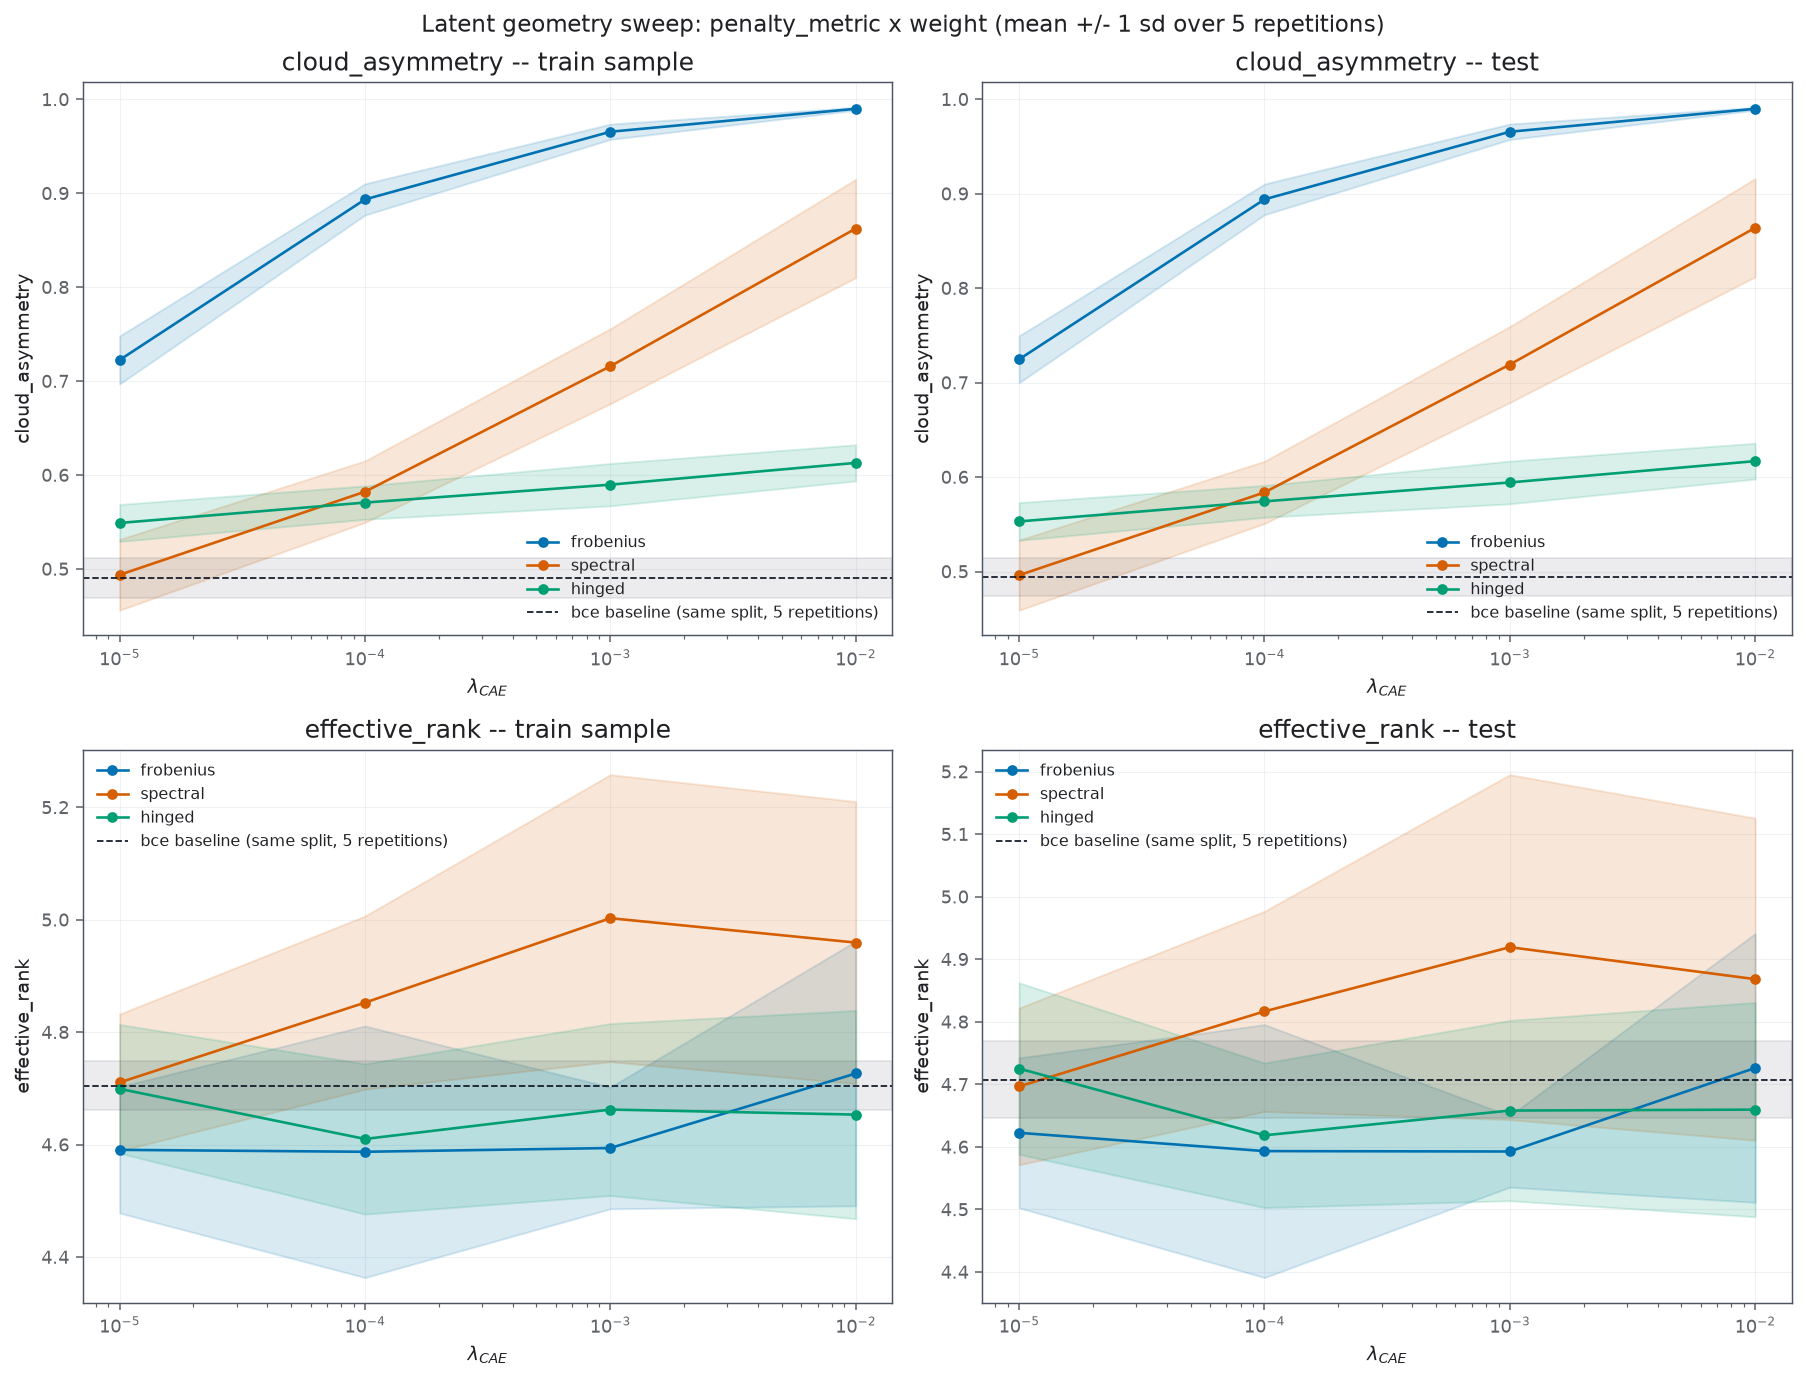

In [8]:
def plot_geometry_sweep(ax, metric_column, split_name, title, higher_is_more_collapsed=True):
    scoped = geometry_frame[geometry_frame["split"] == split_name]
    for metric in PENALTY_METRICS:
        subset = scoped[scoped["penalty_metric"] == metric]
        grouped = subset.groupby("weight")[metric_column].agg(["mean", "std"]).reindex(WEIGHTS)
        ax.plot(grouped.index, grouped["mean"], marker="o", color=METRIC_COLOR[metric], label=metric)
        ax.fill_between(
            grouped.index, grouped["mean"] - grouped["std"], grouped["mean"] + grouped["std"],
            color=METRIC_COLOR[metric], alpha=0.15,
        )
    baseline_values = baseline_geometry_frame[baseline_geometry_frame["split"] == split_name][metric_column]
    ax.axhline(
        baseline_values.mean(), color=theme.baseline_color, linestyle=theme.baseline_line_style,
        linewidth=theme.reference_line_width, label=BASELINE_LABEL,
    )
    ax.axhspan(
        baseline_values.mean() - baseline_values.std(), baseline_values.mean() + baseline_values.std(),
        color=theme.baseline_color, alpha=0.08,
    )
    ax.set_xscale("log")
    ax.set(xlabel=r"$\lambda_{CAE}$", ylabel=metric_column, title=title)
    ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
    ax.legend(fontsize=8, frameon=theme.legend_frame)


figure, axes = plt.subplots(2, 2, figsize=(13.0, 10.0), dpi=theme.figure_dpi)
plot_geometry_sweep(axes[0, 0], "cloud_asymmetry", "train", "cloud_asymmetry -- train sample")
plot_geometry_sweep(axes[0, 1], "cloud_asymmetry", "test", "cloud_asymmetry -- test")
plot_geometry_sweep(axes[1, 0], "effective_rank", "train", "effective_rank -- train sample")
plot_geometry_sweep(axes[1, 1], "effective_rank", "test", "effective_rank -- test")
figure.suptitle("Latent geometry sweep: penalty_metric x weight (mean +/- 1 sd over 5 repetitions)", fontsize=12)
figure.tight_layout()

## Geometry statistics as distributions — every repetition, every cell

### Methodology
#### Theoretical
- The sweep plot above shows mean +/- 1 sd as a line and a shaded band, which can hide
  whether 5 repetitions actually agree or whether the mean is dragged by an outlier
  (`part_6`'s own justification for `plot_violin_with_points` over a mean+band summary).
  This panel shows the raw 5 values behind every `(penalty_metric, weight)` cell of the
  aggregate table above, for each geometry statistic separately.

#### Implementation
- Exact `panel_layout` idiom as `part_6`: one `plot_violin_with_points` per cell at each
  metric, baseline included as its own labeled position. `cloud_asymmetry`,
  `effective_rank`, `trace`, `participation_ratio` each get their own panel (own y-scale --
  they are not on comparable numeric ranges). One full grid per split.

### Notes

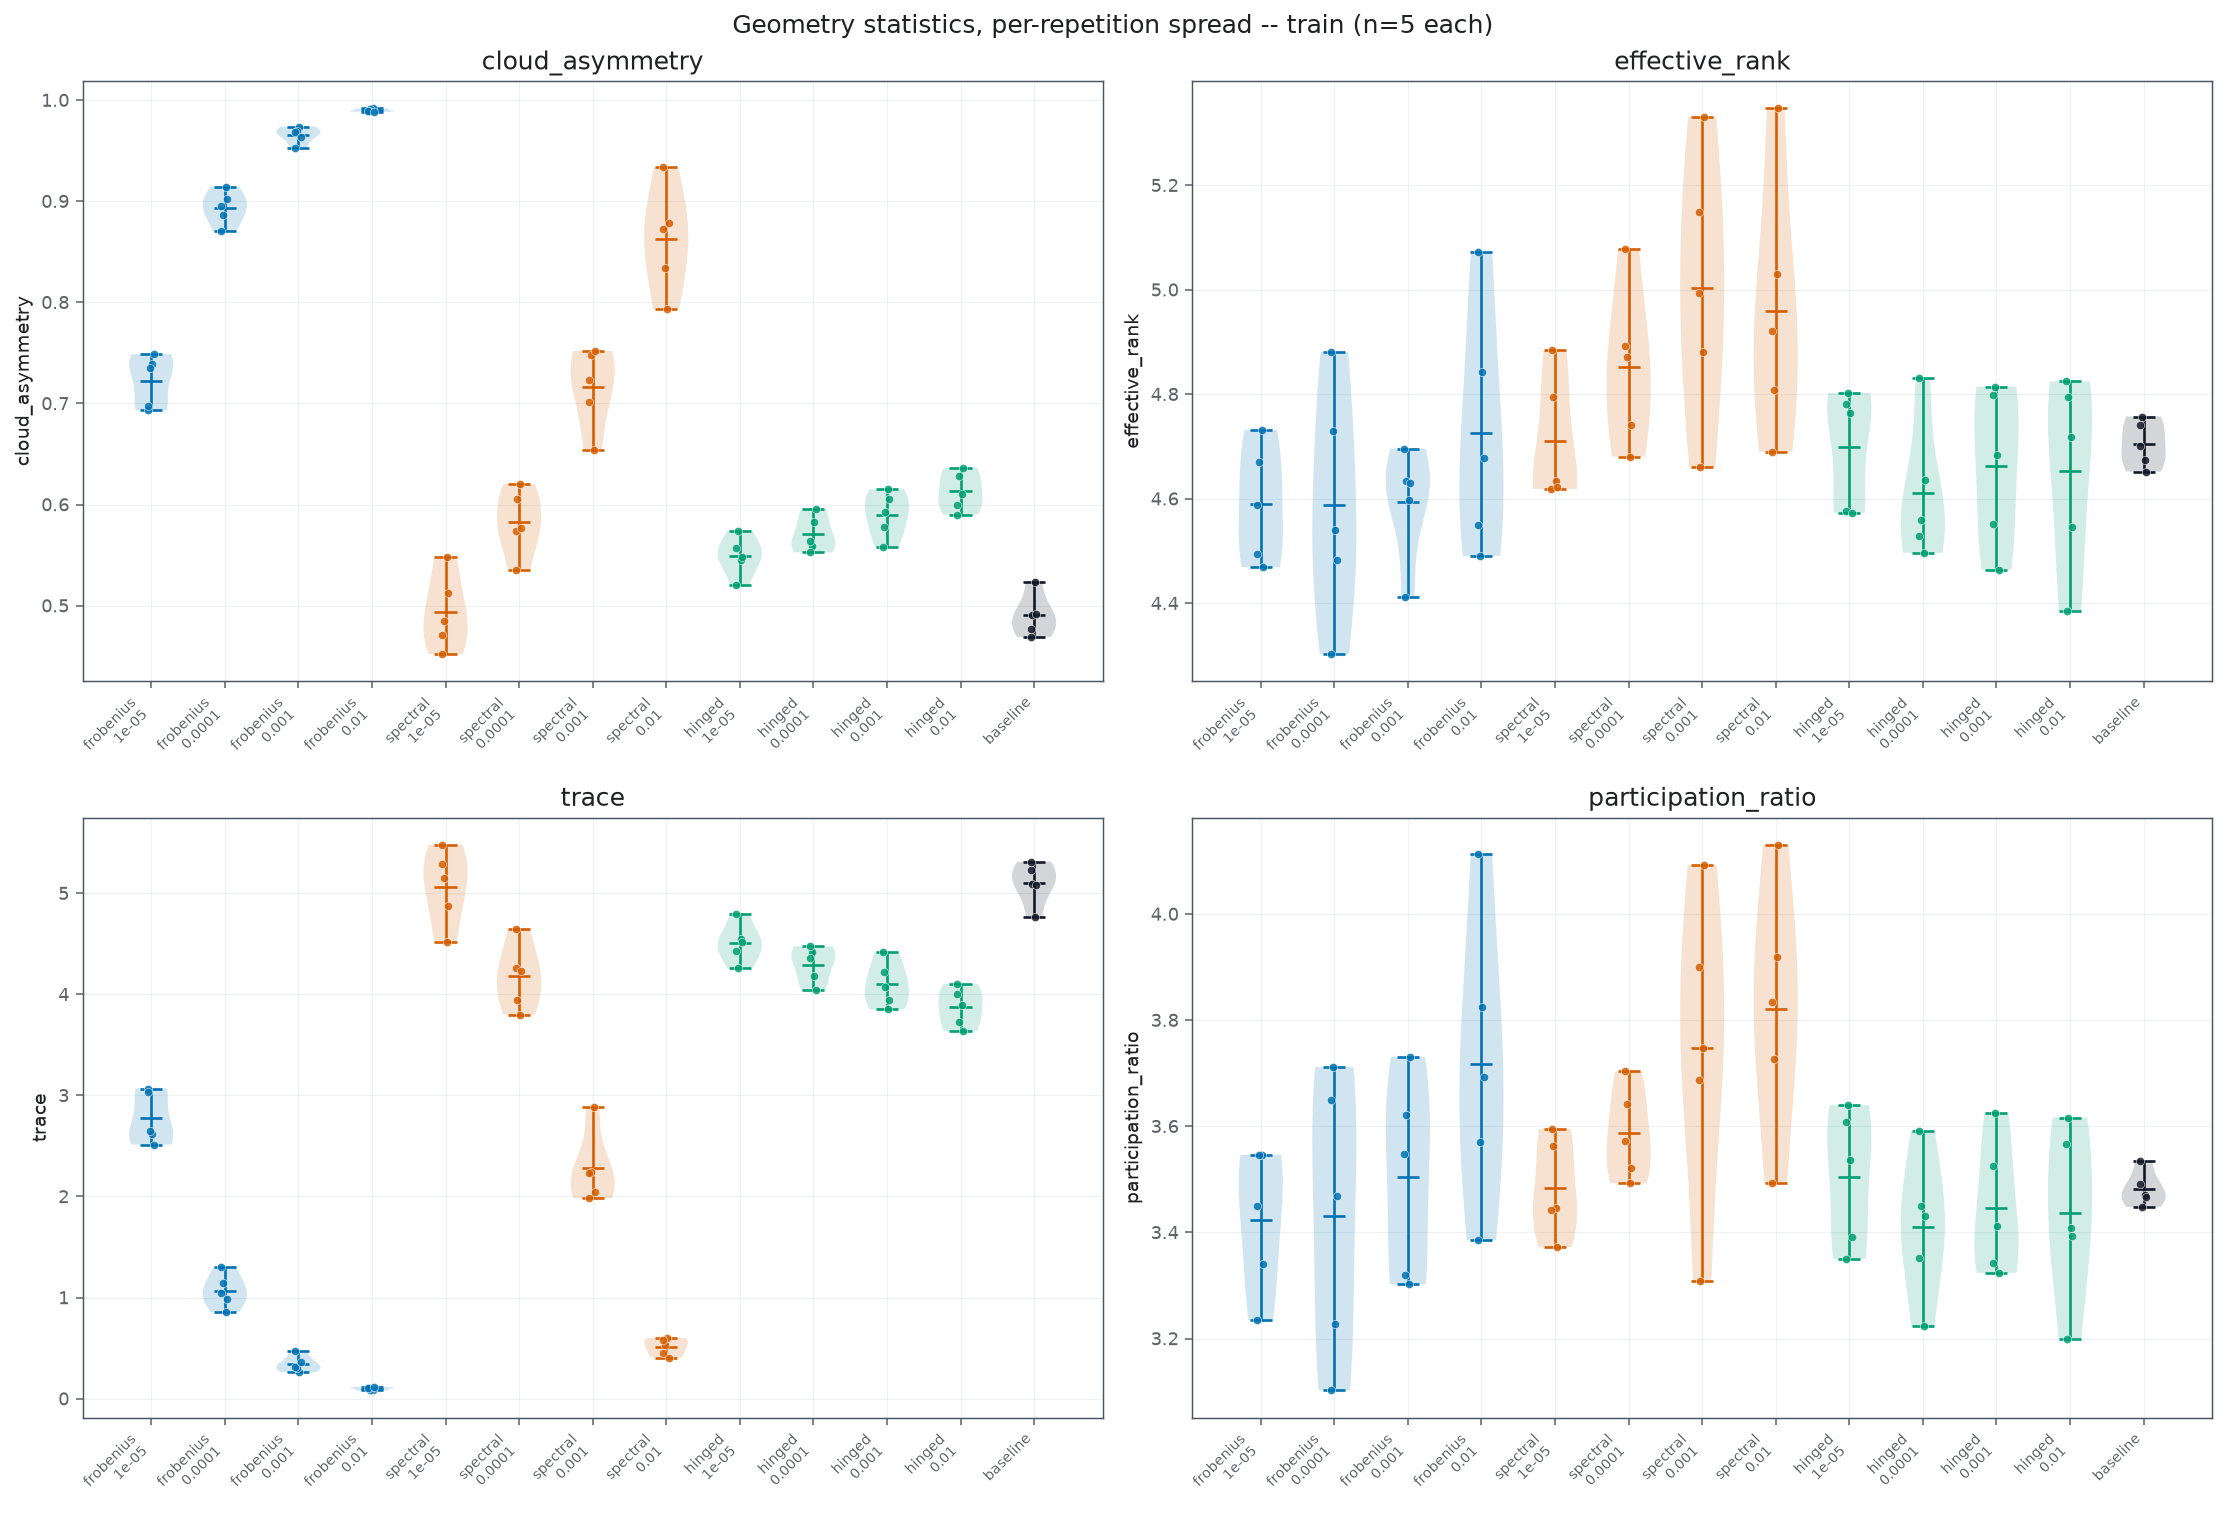

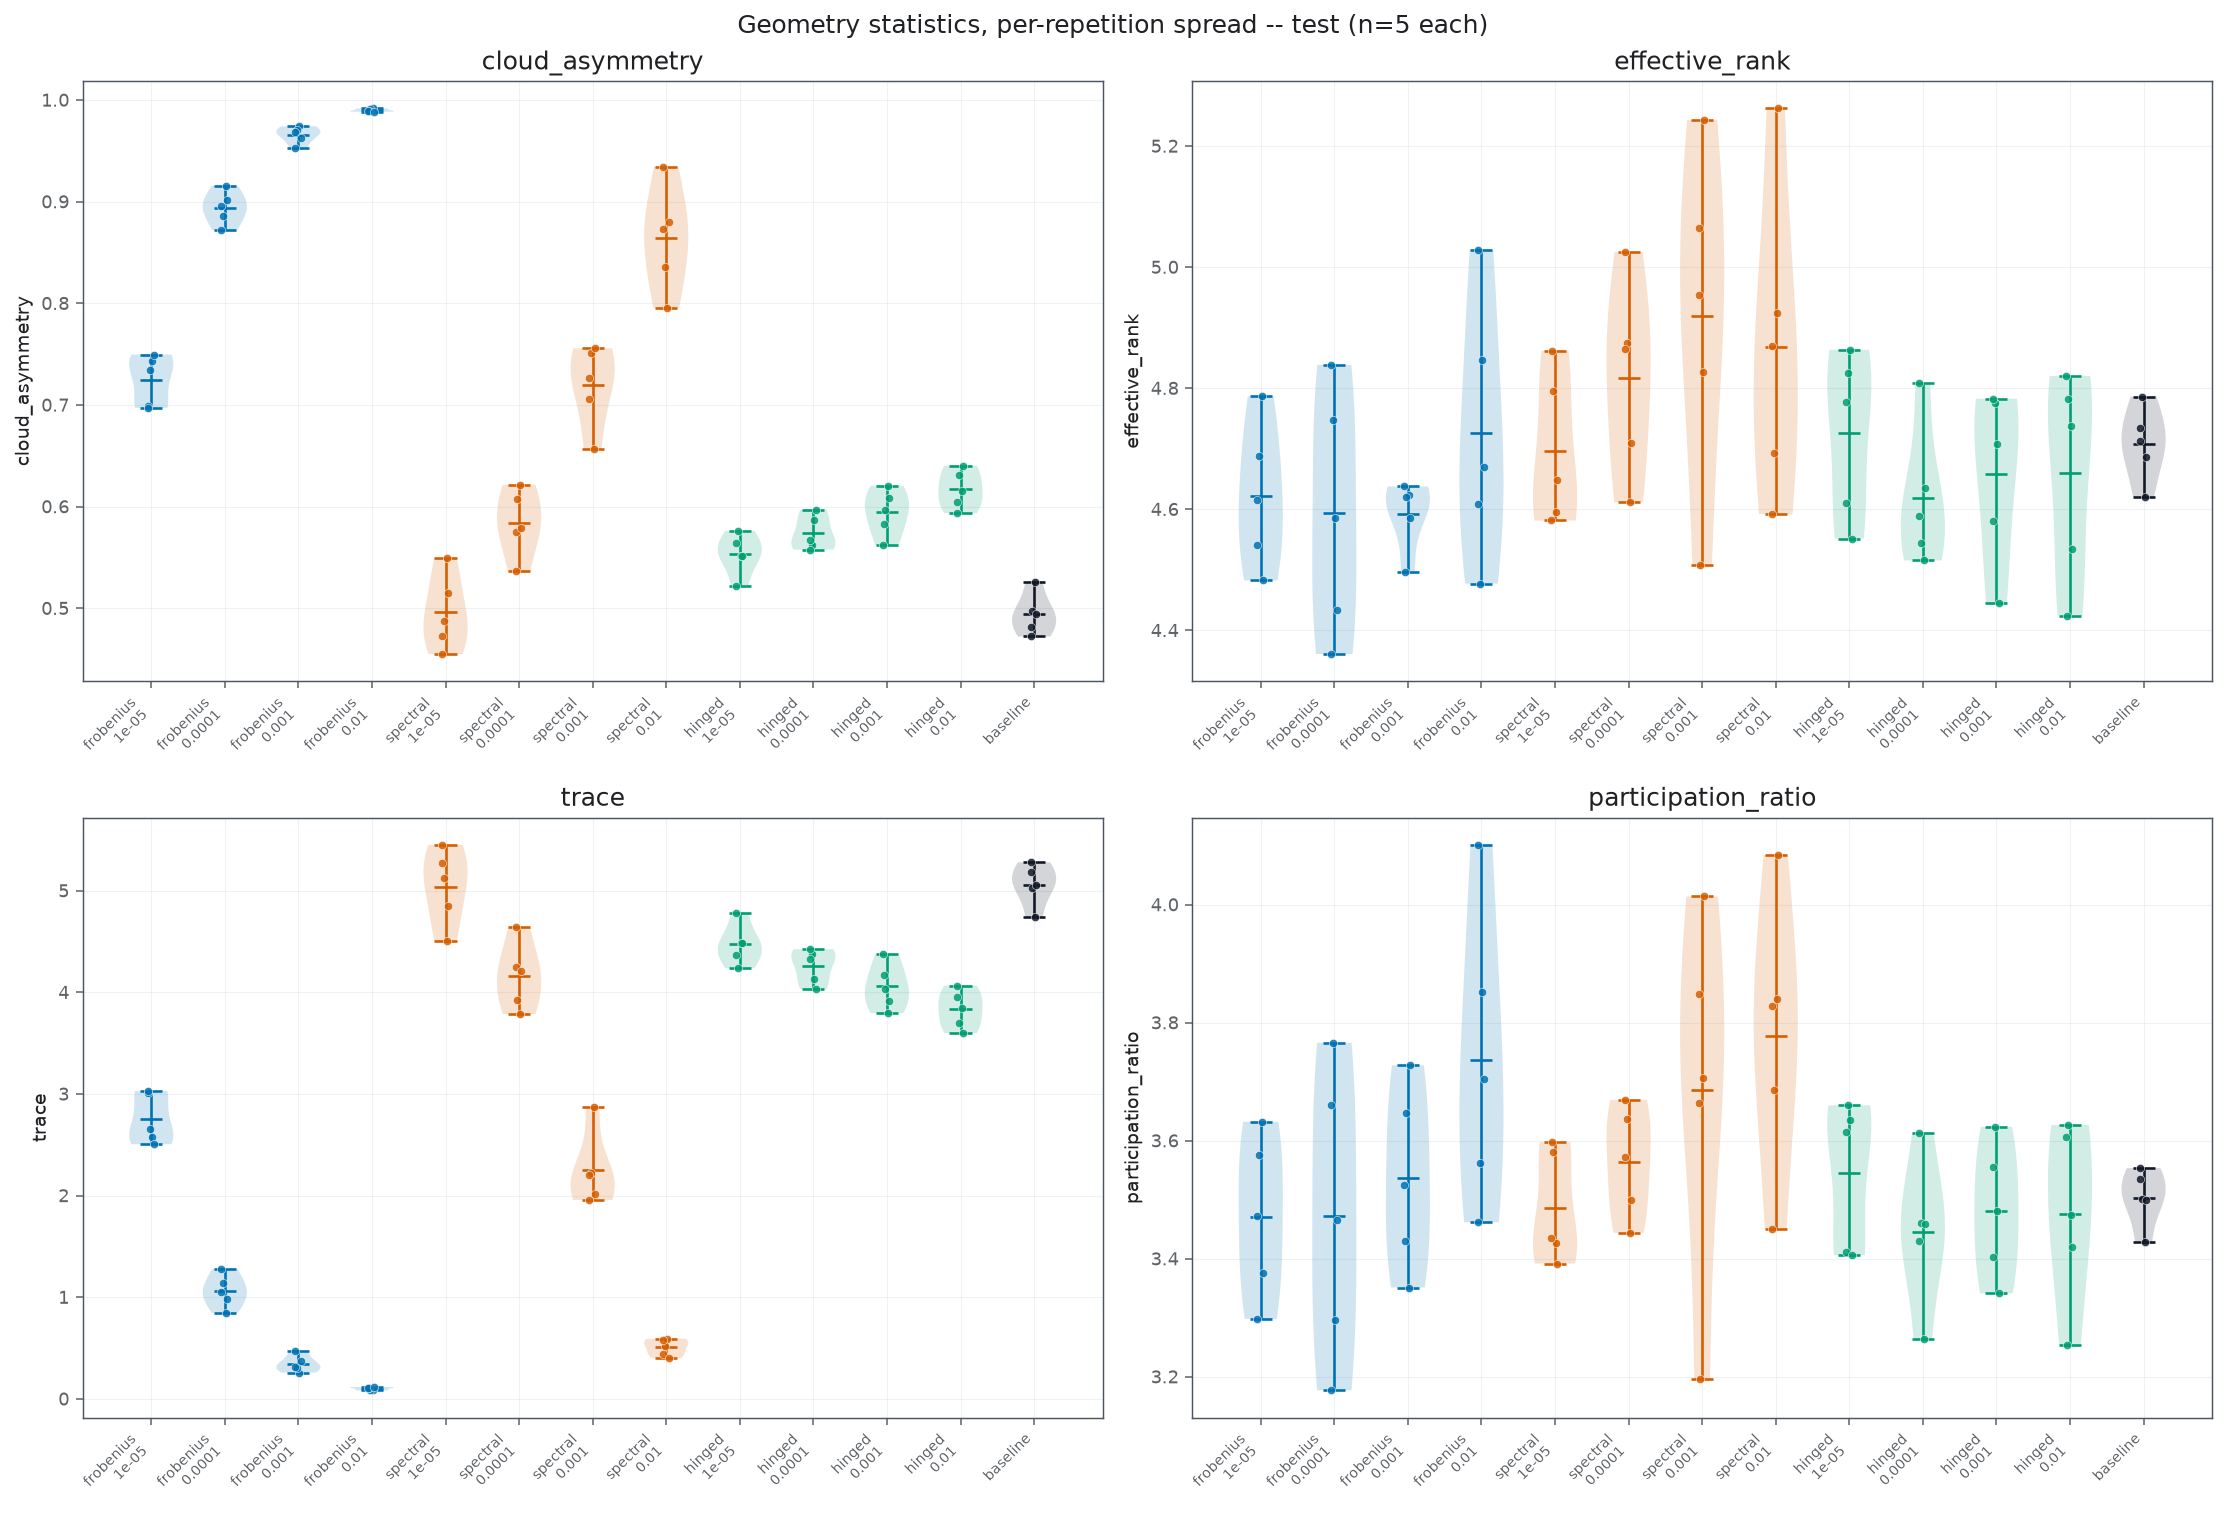

In [9]:
panel_layout = [["cloud_asymmetry", "effective_rank"], ["trace", "participation_ratio"]]

for split_name in materialized:
    scoped = geometry_frame[geometry_frame["split"] == split_name]
    baseline_scoped = baseline_geometry_frame[baseline_geometry_frame["split"] == split_name]
    figure, axes = plt.subplots(len(panel_layout), 2, figsize=(16.0, 5.5 * len(panel_layout)), dpi=theme.figure_dpi)
    for row, metric_row in enumerate(panel_layout):
        for column, metric_name in enumerate(metric_row):
            axis = axes[row, column]
            for position, (metric, weight) in enumerate(cell_order):
                values = scoped.loc[
                    (scoped.penalty_metric == metric) & (scoped.weight == weight), metric_name
                ].to_numpy()
                plot_violin_with_points(values, position=position, ax=axis, width=0.6, color=cell_color[position])
            plot_violin_with_points(
                baseline_scoped[metric_name].to_numpy(), position=len(cell_order), ax=axis, width=0.6,
                color=cell_color[-1],
            )
            axis.set_xticks(range(len(cell_labels)))
            axis.set_xticklabels(cell_labels, rotation=45, ha="right", fontsize=7)
            axis.set(ylabel=metric_name, title=metric_name)
            axis.grid(theme.grid_visible, alpha=theme.grid_alpha)
    figure.suptitle(f"Geometry statistics, per-repetition spread -- {split_name} (n=5 each)", fontsize=13)
    figure.tight_layout()

## Encoder angular sensitivity — repetition 0 only, test pixels

### Methodology
#### Theoretical
- $\varepsilon \mapsto \mathbb{E}\,\angle(u(x), u(x+\varepsilon\lVert x\rVert\delta))$,
  $\delta$ a random unit direction (`geometria_latentu.md` §6.3) — a direct behavioral
  check of encoder smoothness, complementing the static `cloud_asymmetry`/`effective_rank`
  collapse signature above. Restricted to repetition 0 per `(metric, weight)` cell (cost,
  see the introduction).

#### Implementation
- `geometry.angular_sensitivity_curve`, identical call signature to `part_7`, reusing the
  already-materialized `test` tensor from the geometry sweep above (no re-decoding).

### Notes

2026-09-05 17:26:44,614 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:26:44,615 | INFO     | msi_autoencoder_wrapper.models.model_loader:68 | Reconstructing loaded model family 'autoencoder'.


2026-09-05 17:26:44,616 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:173 | Initializing multi-component sub-graph resolution phase for model family: autoencoder


2026-09-05 17:26:44,616 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='encoder' using Strategy='CNNEncoder'.


2026-09-05 17:26:44,621 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:192 | Instantiating standard component sub-module: Category='decoder' using Strategy='CNNDecoder'.


...

2026-09-05 17:26:47,541 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:217 | Instantiating nested sub-module: Collection='heads', Key='molecule_primary' using Strategy='LinearClassificationHead'.


2026-09-05 17:26:47,542 | INFO     | msi_autoencoder_wrapper.models.architectures.architectures_manager:235 | Injecting resolved computational components ledger dictionary into the master architecture graph.


2026-09-05 17:26:47,543 | INFO     | msi_autoencoder_wrapper.models.architectures.types.autoencoders.base_architecture_autoencoder:49 | MSIBaseAutoencoderArchitecture master network graph successfully assembled.


2026-09-05 17:26:47,547 | INFO     | msi_autoencoder_wrapper.utils.module_search:79 | Discovered 29 implementation module(s) in package 'msi_autoencoder_wrapper.models.architectures'.


2026-09-05 17:26:47,551 | INFO     | msi_autoencoder_wrapper.core.mixins.models_manager.proxies.model_runtime_proxy:108 | Attached loaded model 'conv1d-ae-32-16-8-latent-10' as family 'autoencoder'.


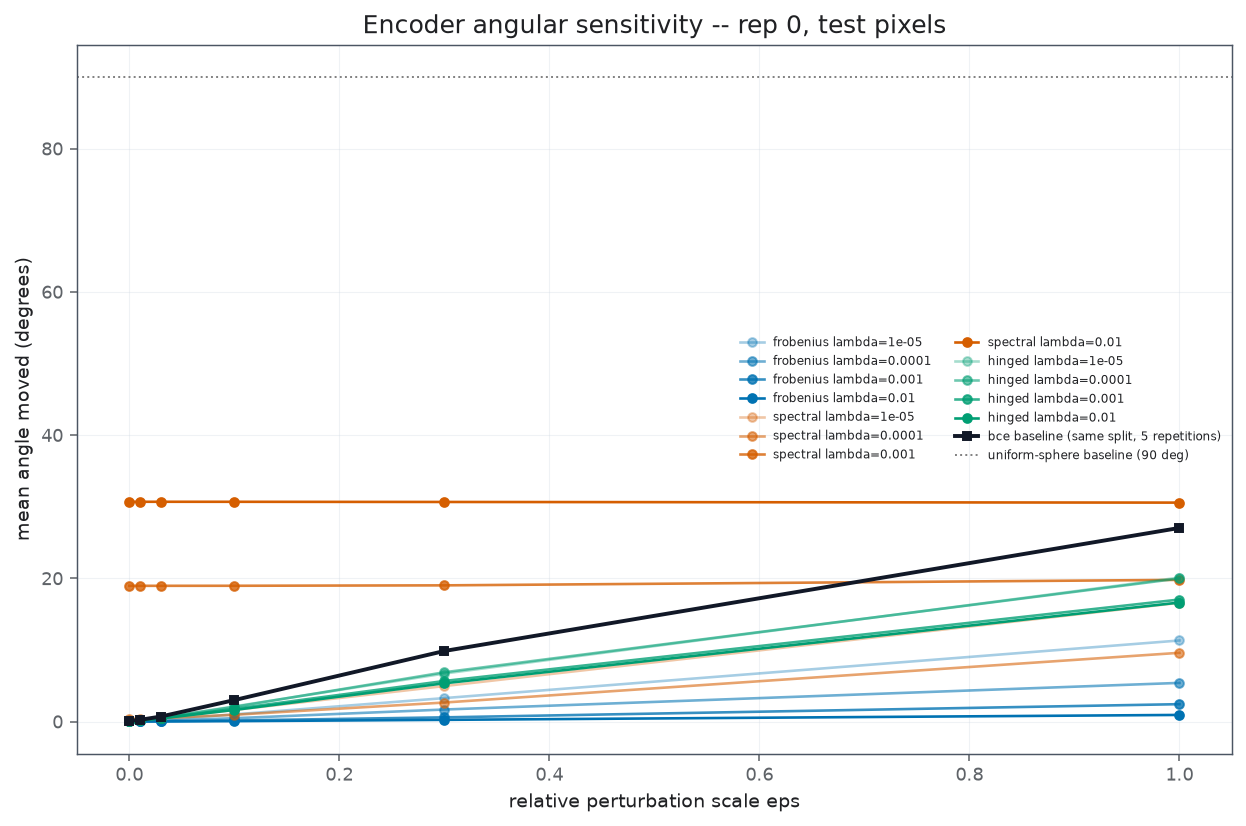

In [10]:
sensitivity_rng = np.random.default_rng(RANDOM_SEED + 3)
test_spectra = materialized["test"]["spectra"].numpy()


def make_encode_fn(model, device, gamma, beta):
    def encode_fn(batch: np.ndarray) -> np.ndarray:
        with torch.no_grad():
            tensor_batch = torch.as_tensor(batch, dtype=torch.float32).to(device)
            z = model(tensor_batch)["latent_space"].cpu().numpy()
        return geometry.canonicalize(z, gamma, beta)

    return encode_fn


sensitivity_rows = []
for metric in PENALTY_METRICS:
    for weight in WEIGHTS:
        model_name = model_name_for(metric, weight, 0)
        model = wrapper.models_manager.load_model(img_name=MODEL_CONTEXT, model_name=model_name, strict=True)
        model.eval()
        device = next(model.parameters()).device
        gamma, beta = geometry.encoder_layer_norm_parameters(model)
        curve = geometry.angular_sensitivity_curve(
            make_encode_fn(model, device, gamma, beta), test_spectra, EPSILONS, sensitivity_rng
        )
        for epsilon, mean_angle in zip(curve["epsilon"], curve["mean_angle_degrees"]):
            sensitivity_rows.append({
                "penalty_metric": metric, "weight": weight,
                "epsilon": float(epsilon), "mean_angle_degrees": float(mean_angle),
            })

baseline_model = wrapper.models_manager.load_model(
    img_name=MODEL_CONTEXT, model_name=baseline_model_name(0), strict=True
)
baseline_model.eval()
baseline_device = next(baseline_model.parameters()).device
baseline_gamma, baseline_beta = geometry.encoder_layer_norm_parameters(baseline_model)
baseline_curve = geometry.angular_sensitivity_curve(
    make_encode_fn(baseline_model, baseline_device, baseline_gamma, baseline_beta),
    test_spectra, EPSILONS, sensitivity_rng,
)

sensitivity_frame = pd.DataFrame(sensitivity_rows)

figure, ax = plt.subplots(figsize=(9.0, 6.0), dpi=theme.figure_dpi)
for metric in PENALTY_METRICS:
    for index, weight in enumerate(WEIGHTS):
        curve = sensitivity_frame[(sensitivity_frame.penalty_metric == metric) & (sensitivity_frame.weight == weight)]
        ax.plot(
            curve["epsilon"], curve["mean_angle_degrees"], marker="o",
            color=METRIC_COLOR[metric], alpha=0.35 + 0.65 * index / (len(WEIGHTS) - 1),
            label=f"{metric} lambda={weight:g}",
        )
ax.plot(baseline_curve["epsilon"], baseline_curve["mean_angle_degrees"], marker="s", color=theme.baseline_color, linewidth=2.0, label=BASELINE_LABEL)
ax.axhline(90.0, color="grey", linestyle=":", linewidth=1, label="uniform-sphere baseline (90 deg)")
ax.set(xlabel="relative perturbation scale eps", ylabel="mean angle moved (degrees)", title="Encoder angular sensitivity -- rep 0, test pixels")
ax.grid(theme.grid_visible, alpha=theme.grid_alpha)
ax.legend(fontsize=6, frameon=theme.legend_frame, ncols=2)
figure.tight_layout()

## RSA-Spearman vs. molecule labels — repetition 0 only

### Methodology
#### Theoretical
- Whether latent angular distance correlates with molecule-label dissimilarity
  (`geometry.rsa_spearman`, `part_7`'s RSA check) across the sweep — checks whether a
  penalty-metric/weight choice that reduces raw collapse also preserves (or restores)
  label-relevant structure, not just unlabelled shape statistics.

#### Implementation
- `geometry.rsa_spearman(u, labels, rng, pair_count)`, repetition 0 only (`part_7`
  precedent), both splits. `labels` reuses the `targets` already captured by
  `materialize_split` above (no re-decoding).

### Notes

In [11]:
rsa_rng = np.random.default_rng(RANDOM_SEED + 2)
rsa_rows = []
for split_name, split_data in materialized.items():
    labels = split_data["targets"]
    for metric in PENALTY_METRICS:
        for weight in WEIGHTS:
            u = u_by_split_cell[(metric, weight, 0, split_name)]
            pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
            result = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=pairs)
            rsa_rows.append({"penalty_metric": metric, "weight": weight, "split": split_name, **result})

baseline_rsa_rows = []
for split_name, split_data in materialized.items():
    labels = split_data["targets"]
    u = u_by_split_baseline_rep[(0, split_name)]
    pairs = min(PAIR_COUNT, u.shape[0] * (u.shape[0] - 1))
    result = geometry.rsa_spearman(u, labels, rsa_rng, pair_count=pairs)
    baseline_rsa_rows.append({"split": split_name, **result})

rsa_frame = pd.DataFrame(rsa_rows)
baseline_rsa_frame = pd.DataFrame(baseline_rsa_rows)
rsa_frame

,penalty_metric,weight,split,spearman_r,p_value,pairs
0,frobenius,0.00001,train,0.357876,0.000000e+00,19997
1,frobenius,0.00010,train,0.336426,0.000000e+00,19997
2,frobenius,0.00100,train,0.357857,0.000000e+00,19998
3,frobenius,0.01000,train,0.361706,0.000000e+00,19999
4,spectral,0.00001,train,0.370923,0.000000e+00,19999
5,spectral,0.00010,train,0.326543,0.000000e+00,19995
6,spectral,0.00100,train,0.329912,0.000000e+00,19996
7,spectral,0.01000,train,0.165508,8.632098e-123,19997
8,hinged,0.00001,train,0.405397,0.000000e+00,19996
9,hinged,0.00010,train,0.388942,0.000000e+00,19996


## Summary for `part_3` (copy the printed dict, no CSV)

Prints the two numbers `part_3`'s decision table needs from this notebook: mean
`effective_rank` and mean `cloud_asymmetry` (test split) per `(penalty_metric, weight)`
cell, plus the baseline means. Copy this dict literal directly into `part_3`'s config cell.

In [12]:
geometry_test_only = geometry_frame[geometry_frame["split"] == "test"]
baseline_geometry_test_only = baseline_geometry_frame[baseline_geometry_frame["split"] == "test"]
geometry_summary = {
    "baseline_effective_rank": float(baseline_geometry_test_only["effective_rank"].mean()),
    "baseline_cloud_asymmetry": float(baseline_geometry_test_only["cloud_asymmetry"].mean()),
    "cells": {
        (metric, weight): {
            "effective_rank": float(
                geometry_test_only[(geometry_test_only.penalty_metric == metric) & (geometry_test_only.weight == weight)][
                    "effective_rank"
                ].mean()
            ),
            "cloud_asymmetry": float(
                geometry_test_only[(geometry_test_only.penalty_metric == metric) & (geometry_test_only.weight == weight)][
                    "cloud_asymmetry"
                ].mean()
            ),
        }
        for metric in PENALTY_METRICS
        for weight in WEIGHTS
    },
}
print("GEOMETRY_SUMMARY =", geometry_summary)

GEOMETRY_SUMMARY = {'baseline_effective_rank': 4.707791385581245, 'baseline_cloud_asymmetry': 0.4942499589207867, 'cells': {('frobenius', 1e-05): {'effective_rank': 4.622549921352927, 'cloud_asymmetry': 0.724697453072117}, ('frobenius', 0.0001): {'effective_rank': 4.593320011943366, 'cloud_asymmetry': 0.8940550515441152}, ('frobenius', 0.001): {'effective_rank': 4.592690195154901, 'cloud_asymmetry': 0.9656131316304977}, ('frobenius', 0.01): {'effective_rank': 4.726261591900529, 'cloud_asymmetry': 0.9899420484737738}, ('spectral', 1e-05): {'effective_rank': 4.696726955829785, 'cloud_asymmetry': 0.4961270093326826}, ('spectral', 0.0001): {'effective_rank': 4.816737937666808, 'cloud_asymmetry': 0.5837586284824954}, ('spectral', 0.001): {'effective_rank': 4.919403418995654, 'cloud_asymmetry': 0.7191693766993806}, ('spectral', 0.01): {'effective_rank': 4.868267258112498, 'cloud_asymmetry': 0.8639544751232071}, ('hinged', 1e-05): {'effective_rank': 4.725250913016749, 'cloud_asymmetry': 0.553

## Closing notes

- **Canonicalization is clean at this subsample**: `max_abs_row_sum` ~1e-6 and
  `max_abs_norm_deviation` at the same scale for every one of the 65 models — no pipeline
  issue introduced by decoding a 15% subsample instead of the full split.
- **The new cos θ structure test adds a finding the summary statistics alone did not
  show: even the baseline is not close to a uniform sphere.** Uniform-sphere null:
  mean cos θ ≈ 0, sd ≈ 0.333. Baseline observed: mean cos θ = 0.522/0.526 (train/test),
  sd = 0.331/0.331 — a moderate, not extreme, concentration, consistent with baseline's own
  `cloud_asymmetry` of 0.494. This means "collapse" here is a matter of *degree* along a
  spectrum baseline already sits partway into, not a binary structured-vs-collapsed split.
  Against that baseline, `frobenius` moves dramatically: mean cos θ climbs 0.741→0.915→
  0.974→0.992 with weight (sd correspondingly collapsing 0.192→0.077→0.024→0.007) —
  by the top weight, essentially every random pair of codes points the same direction.
  `spectral` moves the same direction but less far (0.550→0.618→0.660→0.794, except its
  sd *drops sharply* only at the top weight, 0.32→0.31→0.32→0.058 — a qualitatively
  different, more abrupt transition than `frobenius`'s smooth climb). `hinged` stays
  closest to baseline throughout (0.548→0.583→0.613→0.612, sd 0.29→0.29→0.27→0.27) —
  visibly the tightest cluster of violins around the baseline value in the plot, not just
  the flattest curve in a mean/std sense.
- **`cloud_asymmetry` (the trace-based statistic) tells the same story as the cos θ test,
  as it should — they are two views of the same collapse.** `effective_rank` barely moves
  at all (~4.6-4.9 across all 12 cells, baseline ~4.71) and is not a useful discriminator
  here; `cloud_asymmetry` and the cos θ mean are. `frobenius` and `spectral` both climb
  steeply with weight (`frobenius` most severely — 0.99 at the top weight, matching its
  near-total cos θ collapse above); `hinged` stays in a narrow 0.55-0.62 band throughout —
  the same weight-decoupling behavior `part_1` found for prediction quality, now confirmed
  by two independent geometry statistics, and visibly confirmed in the per-cell violin
  panels (not just the mean±sd sweep lines) — no cell's apparent flatness is an artifact of
  one outlier repetition.
- **RSA-Spearman (angle vs. molecule-label Jaccard) is stable for `frobenius`/`hinged`
  across all four weights** (0.33-0.41, both splits) **but collapses specifically for
  `spectral` at the highest weight** (0.166 train / 0.186 test, vs. 0.33-0.37 at its other
  three weights, p < 1e-122) — a third independent signal, alongside `cloud_asymmetry` and
  the cos θ sd's abrupt drop, that `spectral`@1e-2 is a qualitatively different (more
  sudden) failure mode than `frobenius`'s smooth degradation. Consistent with `part_1`'s
  finding that `spectral`@1e-2 has the second-worst `average_precision` in the sweep.
  `hinged`'s RSA is the most stable of the three metrics throughout (0.388-0.407 test).
- **15% pixel subsample**, same as `part_1` and for the same decode-cost reason
  (`dataset[index]` at ~30 spectra/s across 65 models); static geometry and the cos θ test
  use the full subsample, `angular_sensitivity_curve`/`rsa_spearman` additionally restrict
  to repetition 0 per cell (`part_7`'s own precedent).
